## Figure 1 plots

In [1]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
from results_processing import process_cluster_report, process_cluster_tsv, assign_nested_clusters

# Global plot formatting
plt.rcParams['axes.spines.top'] = False # remove top spine
plt.rcParams['axes.spines.right'] = False # remove right spine
plt.rcParams['pdf.fonttype'] = 42 # Set the fonttype to export fonts as font files
plt.rcParams['font.family'] = 'Arial'
sns.set_palette("colorblind")
global_fontsize = 12
global_color = 'tab:grey'

In [2]:
def add_ground_truth(df, annotations):
    merge = pd.merge(df, annotations[['fullID','trueClusters','pairID','ClusterID']], left_on='query', right_on='fullID', how='left').drop('fullID',axis=1)
    merge.rename(columns={'trueClusters':'if1clust','pairID':'pfamID1','ClusterID':'pfamclust1'}, inplace=True)
    merge2 = pd.merge(merge, annotations[['fullID','trueClusters','pairID','ClusterID']], left_on='target', right_on='fullID', how='left').drop('fullID',axis=1)
    merge2.rename(columns={'trueClusters':'if2clust','pairID':'pfamID2','ClusterID':'pfamclust2'}, inplace=True)

    # Create agreement label to distinguish 'similar' from 'dissimilar' interfaces based on cluster assignment
    merge2.loc[merge2['if1clust'] == merge2['if2clust'], 'agreement'] = 'Same cluster'
    merge2['agreement'] = merge2['agreement'].fillna('Different cluster')

    return merge2

## Load datasets

In [3]:
pdb_clusters = pd.read_csv("/Volumes/imb-luckgr/projects/interface_clustering/results/cluster_analysis/pdb_clusters_annotated.tsv", sep="\t")
pdb_clusters['chain_id_0'] = pdb_clusters['chain_id_0'].fillna('NA')
pdb_clusters['chain_id_1'] = pdb_clusters['chain_id_1'].fillna('NA')
pdb_clusters['chains_sorted'] = pdb_clusters[['chain_id_0','chain_id_1']].apply(lambda x: '_'.join(sorted([str(y) for y in x])), axis=1)
pdb_clusters.loc[:,'simple_pdb_id'] = [x[:4] for x in pdb_clusters['pdb_id']]
pdb_clusters['full_lookup_id'] = pdb_clusters[['simple_pdb_id','chains_sorted']].apply(lambda x: '_'.join([str(y) for y in x]), axis=1)

dmi_clusters = pd.read_csv("/Volumes/imb-luckgr/projects/interface_clustering/datasets/benchmarking/dmi_clusters.csv")
ddi_clusters = pd.read_csv('/Volumes/imb-luckgr/projects/interface_clustering/datasets/benchmarking/ddi_clusters.csv')

/var/folders/8n/b4ym5rbn48v7d2lxw_5ph7z40000gp/T/ipykernel_22812/3168642018.py:1: DtypeWarning: Columns (32,34) have mixed types. Specify dtype option on import or set low_memory=False.
  pdb_clusters = pd.read_csv("/Volumes/imb-luckgr/projects/interface_clustering/results/cluster_analysis/pdb_clusters_annotated.tsv", sep="\t")


## Panel c

In [ ]:
# Accuracy numbers are AUROC1 values calculated in figureS1.ipynb
accs_ddi = [0.966, 0.946, 0.949]
accs_dmi = [0.789, 0.800, 0.809]
times_ddi = [0.020, 3.58, 4.72]
times_dmi = [0.019, 1.63, 2.07]
fold_times_ddi = [np.log2(4.72 / x) for x in times_ddi]
fold_times_dmi = [np.log2(2.07 / x) for x in times_dmi]
print(fold_times_ddi, fold_times_dmi)

[7.882643049361841, 0.3988272720975848, 0.0] [6.767487538943102, 0.3447588032682477, 0.0]


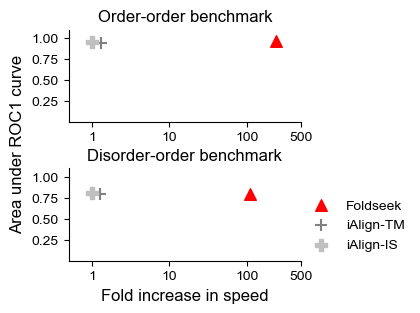

In [5]:
plt.rcParams['axes.spines.top'] = False # remove top spine
plt.rcParams['axes.spines.right'] = False # remove right spine
plt.rcParams['mathtext.default'] = 'default'

fig, (ax1, ax2) = plt.subplots(2,1, figsize=(3,3))
fig.subplots_adjust(hspace=0.5)
fig.set_facecolor('white') #3F3F3F for presentations
ax1.set_facecolor('white')
ax2.set_facecolor('white')
ax1.spines.left.set_color('black')
ax2.spines.left.set_color('black')
ax2.spines.bottom.set_color('black')
ax1.tick_params(axis='both', labelsize=10, labelcolor='black', color='black')
ax2.tick_params(axis='both', labelsize=10, labelcolor='black', color='black')

ax1.set_ylim(0, 1.10)
ax2.set_ylim(0, 1.10)

ax1.set_xlim(-1, 8)
ax2.set_xlim(-1, 8)

ax1.set_yticks([0.25, 0.5, 0.75, 1.0])
ax2.set_yticks([0.25, 0.5, 0.75, 1.0])
ax1.set_xticklabels([])
ax2.set_xticks([0, np.log2(10), np.log2(100), np.log2(500)])
ax2.set_xticklabels(["1", "10", "100", "500"])
ax1.set_xticks([0, np.log2(10), np.log2(100), np.log2(500)])
ax1.set_xticklabels(["1", "10", "100", "500"])

ax2.set_xlabel("Fold increase in speed", fontsize=12)
fig.text(-0.02, 0.5, 'Area under ROC1 curve', va='center', ha='right', rotation='vertical', fontsize=12)

ax1.set_title("Order-order benchmark", fontsize=12)
ax2.set_title("Disorder-order benchmark", fontsize=12)

#Plot
ax1.scatter([fold_times_ddi[0]], [accs_ddi[0]], color='red', marker="^", s=70, label="Foldseek")
ax1.scatter([fold_times_ddi[1]], [accs_ddi[1]], color='gray', marker="+", s=70, label="iAlign-TM")
ax1.scatter([fold_times_ddi[2]], [accs_ddi[2]], color='silver', marker="P", s=70, label="iAlign-IS")
ax2.scatter([fold_times_dmi[0]], [accs_dmi[0]], color='red', marker="^", s=70, label="Foldseek")
ax2.scatter([fold_times_dmi[1]], [accs_dmi[1]], color='gray', marker="+", s=70, label="iAlign-TM")
ax2.scatter([fold_times_dmi[2]], [accs_dmi[2]], color='silver', marker="P", s=70, label="iAlign-IS")

ax2.legend(loc=0, bbox_to_anchor=(1.5,0.8), frameon=False, fontsize=10, title=None)

fig.savefig('/Volumes/imb-luckgr/projects/interface_clustering/visualizations/plots/fs-if-search_acc_runtime.pdf',
           transparent=True,bbox_inches='tight')
fig.savefig('/Volumes/imb-luckgr/projects/interface_clustering/visualizations/plots/fs-if-search_acc_runtime.jpeg',dpi=300,
           transparent=True,bbox_inches='tight')

## Panel d

In [6]:
ddi_aln = pd.read_csv("/Volumes/imb-luckgr/projects/interface_clustering/results/benchmarking/benchmark_alignment/foldseek_ddi_aln_report", sep="\t", header=None)
ddi_aln.columns = ["query","target","qchain","tchain","qtm","ttm","u","t","complexid"]
ddi_aln['query'] = [x.split("_")[-1] for x in ddi_aln["query"]]
ddi_aln['target'] = [x.split("_")[-1] for x in ddi_aln["target"]]

dmi_aln = pd.read_csv("/Volumes/imb-luckgr/projects/interface_clustering/results/benchmarking/benchmark_alignment/foldseek_dmi_aln_report", sep="\t", header=None)
dmi_aln.columns = ["query","target","qchain","tchain","qtm","ttm","u","t","complexid"]
dmi_aln['query'] = [x.split("_")[-1] for x in dmi_aln["query"]]
dmi_aln['target'] = [x.split("_")[-1] for x in dmi_aln["target"]]

ddi_aln = add_ground_truth(ddi_aln, ddi_clusters)
dmi_aln = add_ground_truth(dmi_aln, dmi_clusters)

dmi_aln["dataset"] = ["Disorder-order" for x in dmi_aln.index]
ddi_aln["dataset"] = ["Order-order" for x in ddi_aln.index]

combined = pd.concat([dmi_aln, ddi_aln], axis=0)
combined["mintm"] = combined[["qtm","ttm"]].apply(lambda x: np.nanmin(x), axis=1)
combined.sort_values(by=["agreement","dataset"], ascending=[True,True], inplace=True)
combined

,query,target,qchain,tchain,qtm,ttm,u,t,complexid,if1clust,pfamID1,pfamclust1,if2clust,pfamID2,pfamclust2,agreement,dataset,mintm
8,1a81-IF4006385,7rnu-IF4006505,"A,B","C,D",0.21523,0.33325,"-0.459213,-0.774464,-0.435120,-0.145542,-0.417...","40.291161,100.102875,86.198517",8,46.0,IDIP000132,LIG_TYR_ITAM,8.0,IDIP000132,LIG_SH2_STAT5,Different cluster,Disorder-order,0.21523
9,1a81-IF4006385,7rnu-IF4006506,"A,B","E,F",0.21283,0.34053,"0.037287,0.638447,0.768762,-0.999279,0.029303,...","63.237324,66.900665,118.277664",9,46.0,IDIP000132,LIG_TYR_ITAM,8.0,IDIP000132,LIG_SH2_STAT5,Different cluster,Disorder-order,0.21283
10,1a81-IF4006385,1p13-IF400343,"A,B","B,C",0.20349,0.44397,"0.860932,0.502557,0.078949,-0.465240,0.715031,...","2.296810,22.330456,67.703781",10,46.0,IDIP000132,LIG_TYR_ITAM,0.0,IDIP000132,LIG_SH2_GRB2like,Different cluster,Disorder-order,0.20349
11,1a81-IF4006385,2iui-IF4006316,"A,B","A,C",0.17325,0.28676,"0.255446,0.444442,-0.858614,0.330979,0.794218,...","38.017670,80.959473,78.719925",11,46.0,IDIP000132,LIG_TYR_ITAM,8.0,IDIP000132,LIG_SH2_STAT5,Different cluster,Disorder-order,0.17325
12,1a81-IF4006385,7cio-IF4005420,"A,B","A,B",0.16722,0.28666,"-0.375480,0.249389,-0.892648,0.913770,0.260726...","40.156921,76.859673,87.569984",12,46.0,IDIP000132,LIG_TYR_ITAM,8.0,IDIP000132,LIG_SH2_STAT5,Different cluster,Disorder-order,0.16722
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125701,8dhb-IF458,6wj3-IF470,"A,B","A,B",0.75497,0.88079,"-0.676265,-0.730362,-0.096114,0.534074,-0.3962...","478.662537,338.710358,156.965347",7,15.0,(Gtr1_RagA)(LAMTOR),1.0,15.0,(Gtr1_RagA)(LAMTOR),1.0,Same cluster,Order-order,0.75497
125702,8dhb-IF458,6wj2-IF471,"A,B","A,B",0.71696,0.85685,"0.647640,-0.761924,-0.005911,-0.527990,-0.4543...","251.952972,284.441803,532.147705",8,15.0,(Gtr1_RagA)(LAMTOR),1.0,15.0,(Gtr1_RagA)(LAMTOR),1.0,Same cluster,Order-order,0.71696
125703,8dhb-IF458,7t3c-IF460,"A,B","B,A",0.68944,0.73440,"-0.179590,0.392489,-0.902053,-0.407723,-0.8641...","321.748108,565.880615,311.155396",9,15.0,(Gtr1_RagA)(LAMTOR),1.0,15.0,(Gtr1_RagA)(LAMTOR),1.0,Same cluster,Order-order,0.68944
125704,8dhb-IF458,6jwp-IF467,"A,B","A,B",0.66258,0.66258,"-0.980590,0.144609,0.132409,-0.185249,-0.90455...","255.964661,388.853821,268.548035",10,15.0,(Gtr1_RagA)(LAMTOR),1.0,15.0,(Gtr1_RagA)(LAMTOR),1.0,Same cluster,Order-order,0.66258


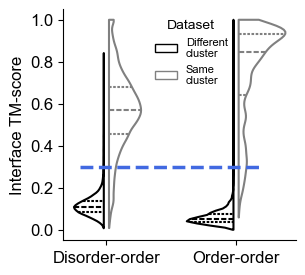

In [10]:
legend_elements = [mpl.patches.Patch(facecolor="white", edgecolor="black", label="Different\ncluster"),
                   mpl.patches.Patch(facecolor="white", edgecolor="gray", label="Same\ncluster")]

fig, ax = plt.subplots(figsize=(3,3))
sns.violinplot(data=combined, x='dataset', y='mintm', hue="agreement", fill=None, split=True, inner="quart", cut=0, gap=0.1, palette=["black","gray"], ax=ax)
ax.set_xlabel(None)
ax.set_ylabel('Interface TM-score', fontsize=global_fontsize)
ax.tick_params(axis='both', labelsize=global_fontsize)
ax.legend(handles=legend_elements, loc=0, bbox_to_anchor=(0.35,1.0), frameon=False, fontsize=8, title="Dataset")
ax.hlines(y=0.3, xmin=-0.2, xmax=1.2, linewidth=2.5, color='royalblue', linestyles="dashed")

fig.savefig('/Volumes/imb-luckgr/projects/interface_clustering/visualizations/plots/fs-if-search_bmark_tmscore_dists.pdf',
           transparent=True,bbox_inches='tight')
fig.savefig('/Volumes/imb-luckgr/projects/interface_clustering/visualizations/plots/fs-if-search_bmark_tmscore_dists.jpeg',dpi=300,
           transparent=True,bbox_inches='tight')

## Panel e

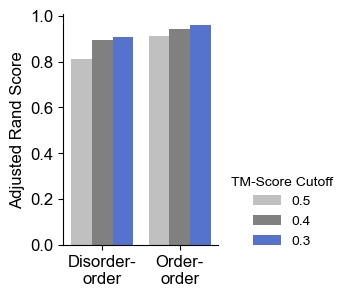

In [ ]:
# ARS values calculated in process_cluster_benchmark.ipynb
ars = [0.813, 0.895, 0.905, 0.910, 0.944, 0.960]
labels = ["Disorder-\norder","Disorder-\norder","Disorder-\norder","Order-\norder","Order-\norder","Order-\norder"]
cutoffs = ["0.5","0.4","0.3","0.5","0.4","0.3"]

plot_df = pd.DataFrame({"ars":ars, "labels":labels, "cutoffs":cutoffs})

fig, ax = plt.subplots(figsize=(2,3))
sns.barplot(data=plot_df, x="labels", y="ars", hue="cutoffs", palette=["silver","gray","royalblue"], ax=ax)
ax.legend(loc=0, bbox_to_anchor=(1.0,0.35), frameon=False, fontsize=10, title="TM-Score Cutoff")
ax.set_xlabel(None)
ax.set_ylabel("Adjusted Rand Score", fontsize=12)
ax.tick_params(axis="both", labelsize=12)

fig.savefig('/Volumes/imb-luckgr/projects/interface_clustering/visualizations/plots/fs-if-cluster_bmark_ars.pdf',
           transparent=True,bbox_inches='tight')
fig.savefig('/Volumes/imb-luckgr/projects/interface_clustering/visualizations/plots/fs-if-cluster_bmark_ars.jpeg',dpi=300,
           transparent=True,bbox_inches='tight')

## Panel f

In [ ]:
dmi_clusters.loc[:,'chains'] = dmi_clusters[['motif chain','domain chain']].apply(lambda x: '_'.join(sorted([str(y) for y in x])), axis=1)
dmi_clusters.loc[:,'full_lookup_id'] = dmi_clusters[['pdb_id','chains']].apply(lambda x: '_'.join([str(y) for y in x]), axis=1)
dmi_merge = pd.merge(dmi_clusters, pdb_clusters, on='full_lookup_id', how='left')

print(dmi_merge.shape[0])
print(dmi_merge.loc[dmi_merge['intcluster'].isna(),["pdb_id_x","chains"]])
print(dmi_merge.loc[dmi_merge["IFID"].duplicated(keep=False), ["pdb_id_y","intcluster", "chains"]])
dmi_merge.drop_duplicates(subset="IFID", keep="first", inplace=True)
dmi_merge.dropna(subset="intcluster", axis=0, inplace=True)
print(dmi_merge.shape[0])

dmi_merge[((dmi_merge["elm_identifier"] == "DOC_MAPK_MEF2A_6") | (dmi_merge["elm_identifier"] == "DOC_MAPK_NFAT4_5"))][["elm_identifier","full_lookup_id","intcluster","dimerrep","intrep"]]

839
    pdb_id_x chains
117     3lnz    K_L
201     6ygj    F_I
564     4gk5    E_G
           pdb_id_y  intcluster chains
21   3eqs-assembly1     56505.0    A_B
22   3eqs-assembly2     56505.0    A_B
32   2axi-assembly1     56505.0    A_B
33   2axi-assembly2     56505.0    A_B
34   2axi-assembly3     56505.0    A_B
..              ...         ...    ...
776  1a81-assembly8      3637.0    E_F
777  1a81-assembly2      3637.0    C_D
778  1a81-assembly3      3637.0    C_D
779  1a81-assembly2      3637.0    A_B
780  1a81-assembly6      3637.0    A_B

[112 rows x 3 columns]
775


,elm_identifier,full_lookup_id,intcluster,dimerrep,intrep
137,DOC_MAPK_MEF2A_6,4loq_D_N,63151.0,1.0,0.0
138,DOC_MAPK_MEF2A_6,4loo_A_B,57529.0,1.0,0.0
139,DOC_MAPK_MEF2A_6,4loq_A_M,57529.0,1.0,0.0
140,DOC_MAPK_MEF2A_6,4loq_B_L,57529.0,0.0,0.0
141,DOC_MAPK_MEF2A_6,4loq_C_K,57529.0,1.0,0.0
142,DOC_MAPK_MEF2A_6,4lop_C_K,57529.0,0.0,0.0
143,DOC_MAPK_MEF2A_6,4lop_B_L,57529.0,0.0,0.0
144,DOC_MAPK_MEF2A_6,4lop_D_N,57529.0,1.0,0.0
145,DOC_MAPK_MEF2A_6,1lew_A_B,63151.0,0.0,0.0
146,DOC_MAPK_MEF2A_6,5o90_A_B,57529.0,1.0,1.0
